# Olympic Athlete & Medal Visualization

Exploratory analysis of historical Olympic athlete-event records, with a focus on the 2012 and 2016 Summer Games.

This project demonstrates how different chart types answer different questions: ranked bar charts for category comparison, distribution plots for athlete demographics, violin plots for grouped distributions, and Plotly for interactive composition analysis.

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly


## 1. Data setup

The analysis expects `data/olympic_athletes.csv`. Each row represents an athlete competing in an Olympic event, so medal counts in this notebook are **medal-winning athlete-event records**, not official country medal-table totals.


In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

DATA_PATH = "data/olympic_athletes.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [ ]:
df.shape, df.columns.tolist()


## 2. Preparing medalist subsets

Two event years are used for comparison. Medal-winning records are separated from the full athlete dataset so the visualizations consistently represent awarded medals.


In [ ]:
medalists_2012 = df.loc[(df["Year"] == 2012) & df["Medal"].notna()].copy()
medalists_2016 = df.loc[(df["Year"] == 2016) & df["Medal"].notna()].copy()

print(f"2012 medal records: {len(medalists_2012):,}")
print(f"2016 medal records: {len(medalists_2016):,}")


## 3. Sports with the most medal-winning records in 2012

A horizontal bar chart highlights the sports with the largest number of medal-winning athlete-event records while keeping category labels readable.


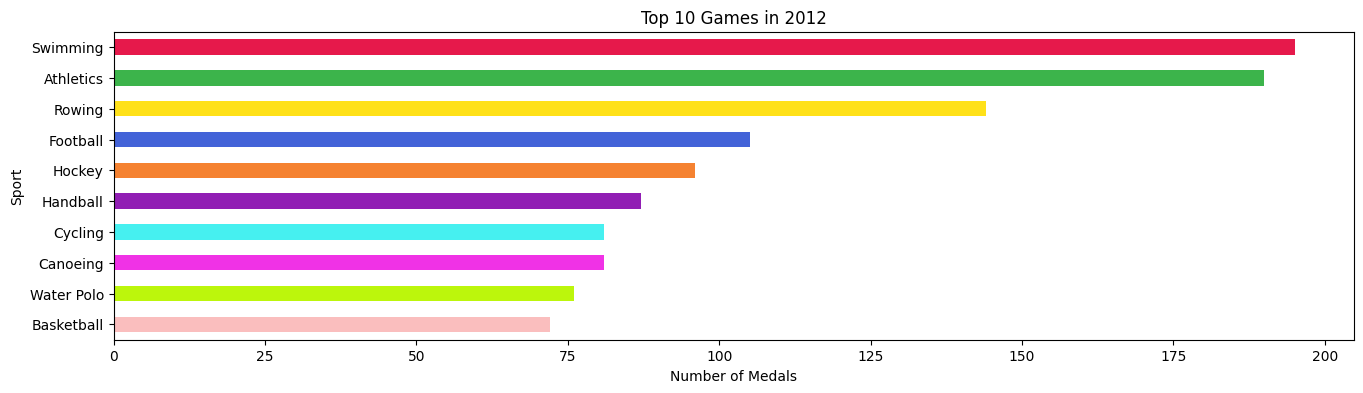

In [ ]:
top_10_sports = medalists_2012["Sport"].value_counts().head(10)
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
          '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe']

ax = top_10_sports.plot(kind="barh", figsize=(16, 4), color=colors)
ax.invert_yaxis()
ax.set_title("Top 10 Sports by Medal-Winning Records — 2012")
ax.set_xlabel("Number of medal records")
ax.set_ylabel("Sport")
plt.tight_layout()
plt.show()


## 4. U.S. medal-record composition by gender

For the United States, side-by-side pie charts compare the Gold, Silver, and Bronze composition of medal-winning athlete-event records for male and female athletes.


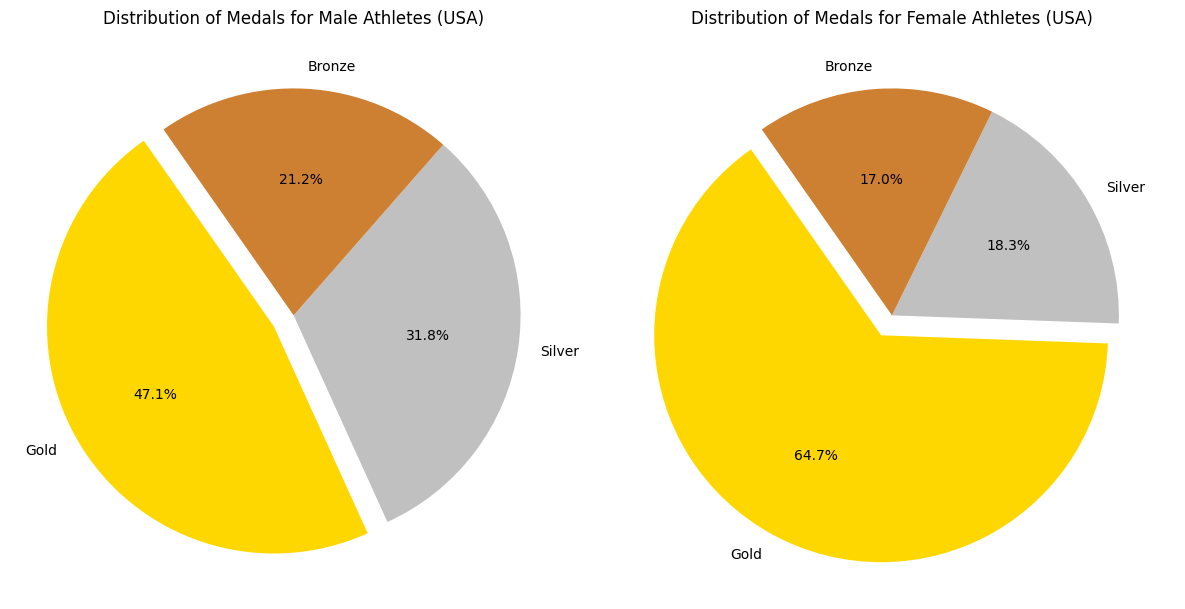

In [ ]:
usa_2012 = medalists_2012[medalists_2012["Team"] == "United States"]
male_usa = usa_2012[usa_2012["Sex"] == "M"]
female_usa = usa_2012[usa_2012["Sex"] == "F"]

medal_order = ["Gold", "Silver", "Bronze"]
medal_colors = ['#FFD700', '#C0C0C0', '#CD7F32']
explode = [0.1, 0, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(male_usa["Medal"].value_counts().reindex(medal_order, fill_value=0),
        labels=medal_order, colors=medal_colors, autopct="%1.1f%%",
        explode=explode, startangle=125)
ax1.set_title("Distribution of Medals for Male Athletes (USA)")

ax2.pie(female_usa["Medal"].value_counts().reindex(medal_order, fill_value=0),
        labels=medal_order, colors=medal_colors, autopct="%1.1f%%",
        explode=explode, startangle=125)
ax2.set_title("Distribution of Medals for Female Athletes (USA)")

plt.tight_layout()
plt.show()


## 5. Athlete age vs. height

The scatter plot explores the relationship between age and height among 2012 medalists. This view is useful for spotting clusters, broad patterns, and unusual observations.


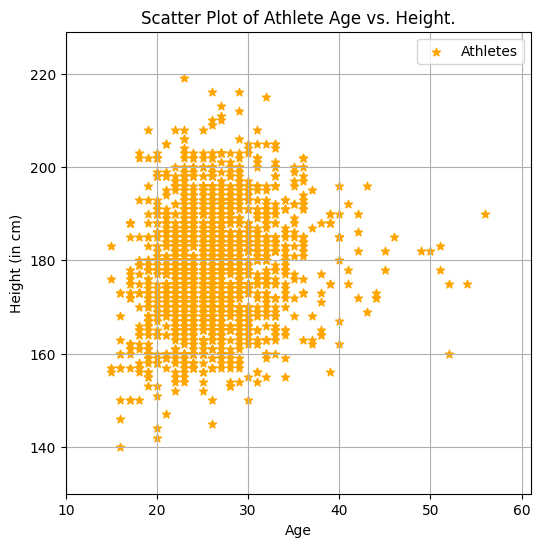

In [ ]:
athlete_size = medalists_2012.dropna(subset=["Age", "Height"]).copy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(athlete_size["Age"], athlete_size["Height"],
           marker="*", color="orange", label="Athletes")
ax.set_title("Athlete Age vs. Height — 2012 Medalists")
ax.set_xlabel("Age")
ax.set_ylabel("Height (cm)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Athlete age distribution

The histogram shows the overall age distribution of 2012 medalists. A KDE comparison then shows how the age profile varies across Gold, Silver, and Bronze records.


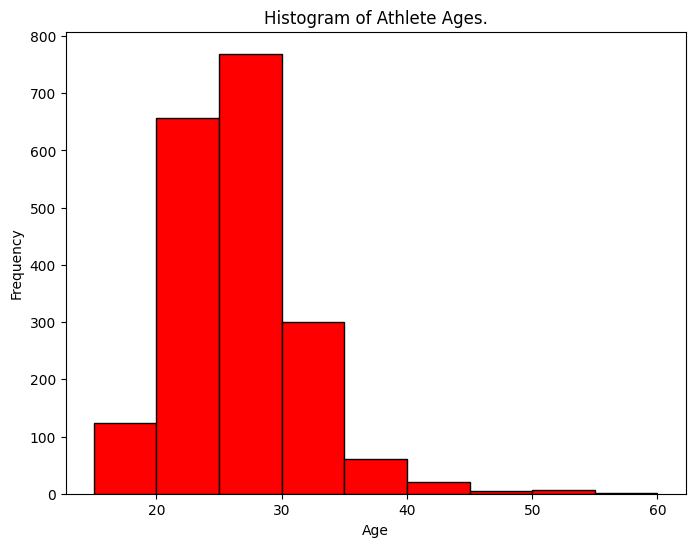

In [ ]:
ages = medalists_2012["Age"].dropna()
bins = np.arange(ages.min(), ages.max() + 5, 5)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(ages, bins=bins, color="red", edgecolor="black")
ax.set_title("Histogram of Athlete Ages.")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


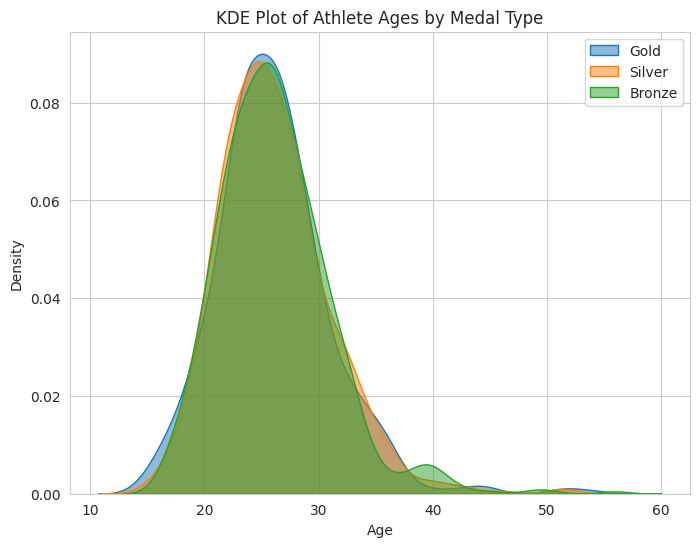

In [ ]:
age_by_medal = medalists_2012.dropna(subset=["Age"]).copy()

plt.figure(figsize=(8, 6))
for medal in ["Gold", "Silver", "Bronze"]:
    sns.kdeplot(
        data=age_by_medal[age_by_medal["Medal"] == medal],
        x="Age",
        fill=True,
        alpha=0.35,
        label=medal,
    )

plt.title("Age Density by Medal Type — 2012")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend(title="Medal")
plt.tight_layout()
plt.show()


## 7. Height and weight distributions by medal type and gender

Violin plots combine density and categorical comparison, making it easier to compare body-metric distributions across medal type and gender.


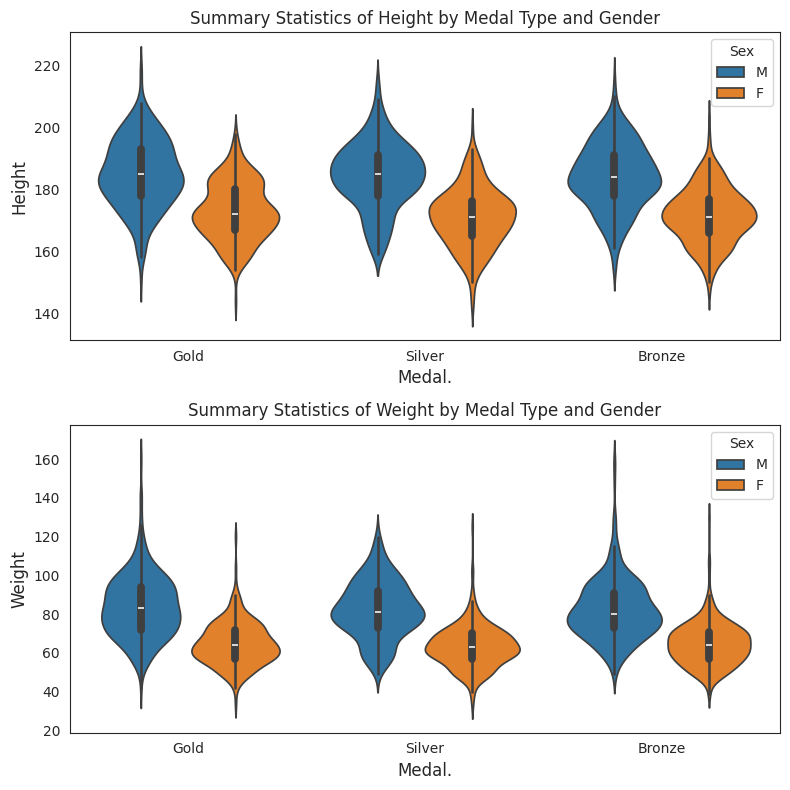

In [ ]:
body_metrics = medalists_2012.dropna(subset=["Height", "Weight"]).copy()
medal_order = ["Gold", "Silver", "Bronze"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9))

sns.violinplot(data=body_metrics, x="Medal", y="Height", hue="Sex",
               order=medal_order, ax=ax1)
ax1.set_title("Height Distribution by Medal Type and Gender")
ax1.set_xlabel("Medal")
ax1.set_ylabel("Height (cm)")

sns.violinplot(data=body_metrics, x="Medal", y="Weight", hue="Sex",
               order=medal_order, ax=ax2)
ax2.set_title("Weight Distribution by Medal Type and Gender")
ax2.set_xlabel("Medal")
ax2.set_ylabel("Weight (kg)")

plt.tight_layout()
plt.show()


## 8. Interactive team comparison

The five teams with the most medal-winning athlete-event records in 2012 are compared with a stacked Plotly bar chart. The United States leads this athlete-level count, followed by Russia, Great Britain, China, and Australia.


In [ ]:
team_totals = (
    medalists_2012.groupby("Team")["Medal"]
    .count()
    .sort_values(ascending=False)
    .head(5)
)

top_teams = team_totals.index.tolist()
team_medal_counts = (
    medalists_2012[medalists_2012["Team"].isin(top_teams)]
    .groupby(["Team", "Medal"])
    .size()
    .reset_index(name="Count")
)

medal_color_map = {"Gold": "#ffd700", "Silver": "#c0c0c0", "Bronze": "#cd7f32"}

fig = px.bar(
    team_medal_counts,
    x="Team",
    y="Count",
    color="Medal",
    barmode="stack",
    title="Top 5 Teams by Medal-Winning Athlete-Event Records — 2012",
    color_discrete_map=medal_color_map,
    category_orders={"Team": top_teams, "Medal": ["Bronze", "Silver", "Gold"]},
)
fig.show()


## 9. Reusing the workflow for 2016

The same filtering and ranking approach is applied to 2016 to show how a visualization workflow can be reused across event years.


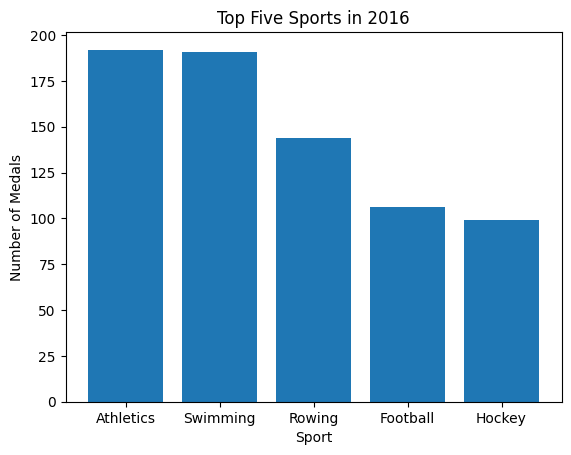

In [ ]:
top_5_sports_2016 = medalists_2016["Sport"].value_counts().head(5)

ax = top_5_sports_2016.plot(kind="bar", figsize=(9, 4))
ax.set_title("Top Five Sports in 2016")
ax.set_xlabel("Sport")
ax.set_ylabel("Number of medal records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


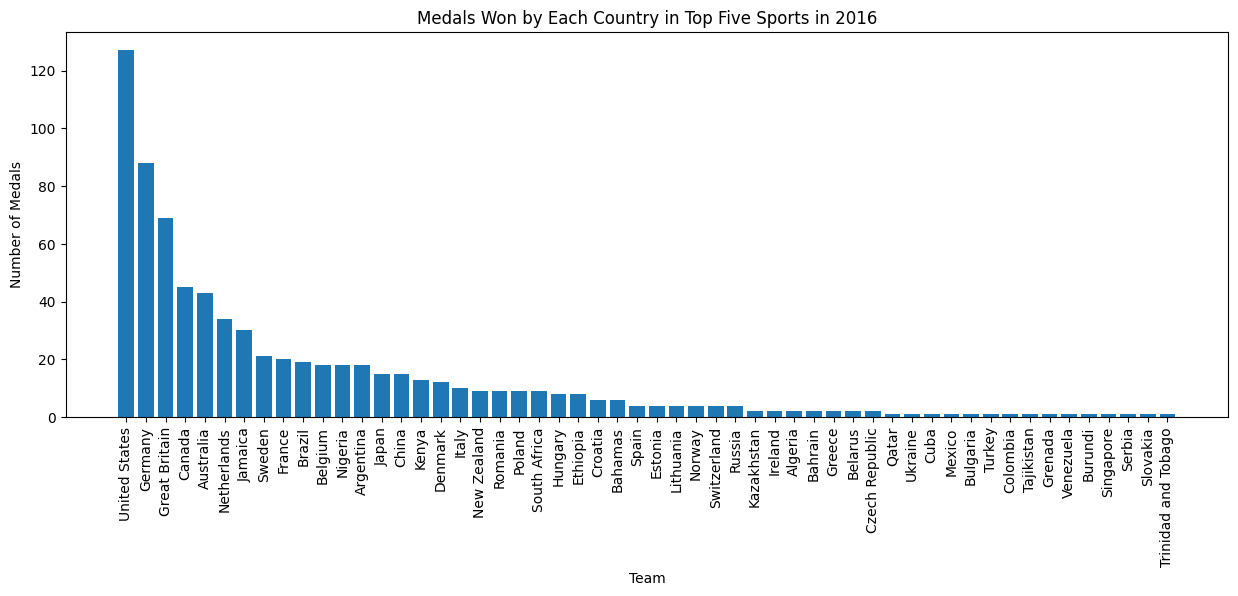

In [ ]:
top_sport_records_2016 = medalists_2016[
    medalists_2016["Sport"].isin(top_5_sports_2016.index)
]
team_counts_2016 = top_sport_records_2016["Team"].value_counts().head(20)

ax = team_counts_2016.plot(kind="bar", figsize=(14, 5))
ax.set_title("Medals Won by Each Country in Top Five Sports in 2016")
ax.set_xlabel("Team")
ax.set_ylabel("Number of medal records")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


## 10. Key takeaways

- The project combines categorical, distributional, multivariate, and interactive visualization techniques in one analysis workflow.
- The 2012 team comparison shows the United States with the largest number of medal-winning athlete-event records among the top five teams in this dataset.
- Athlete-level Olympic data requires careful labeling: team-event medals appear once per athlete, so these counts should not be interpreted as official medal-table totals.
- The same analysis pattern can be reused across Olympic years with minimal changes to filtering logic.
